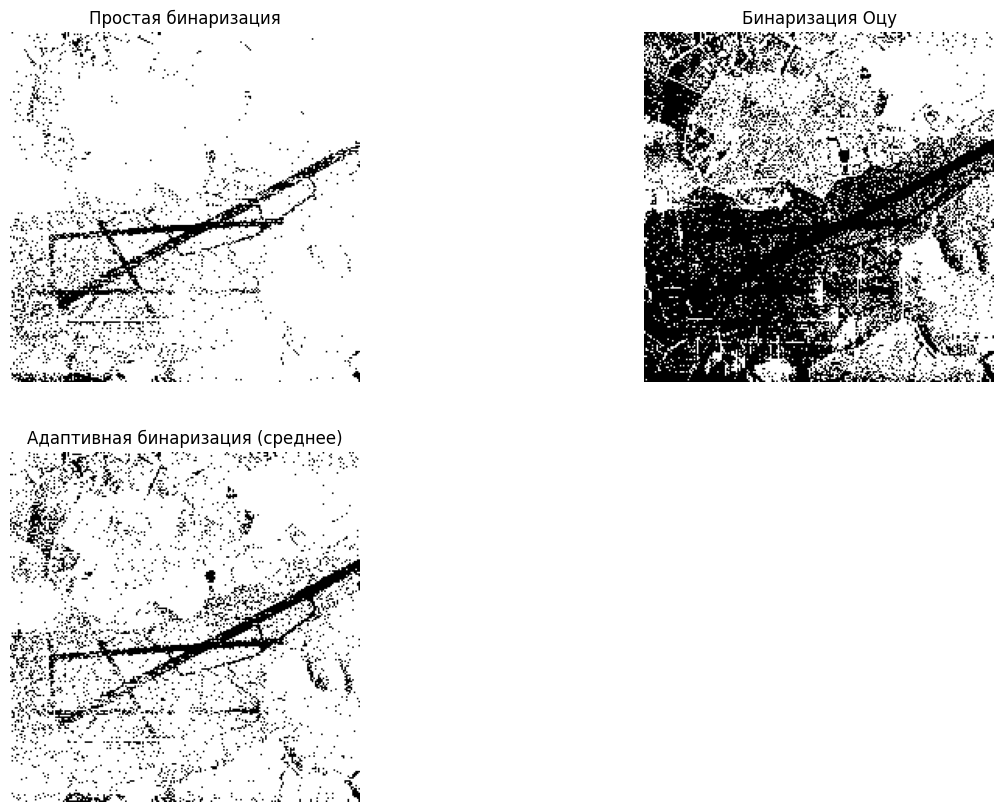

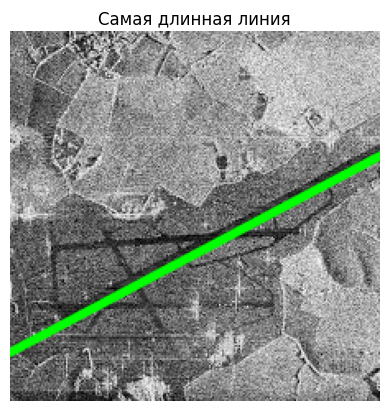

Длина самой длинной линии: 1998.77 пикселей


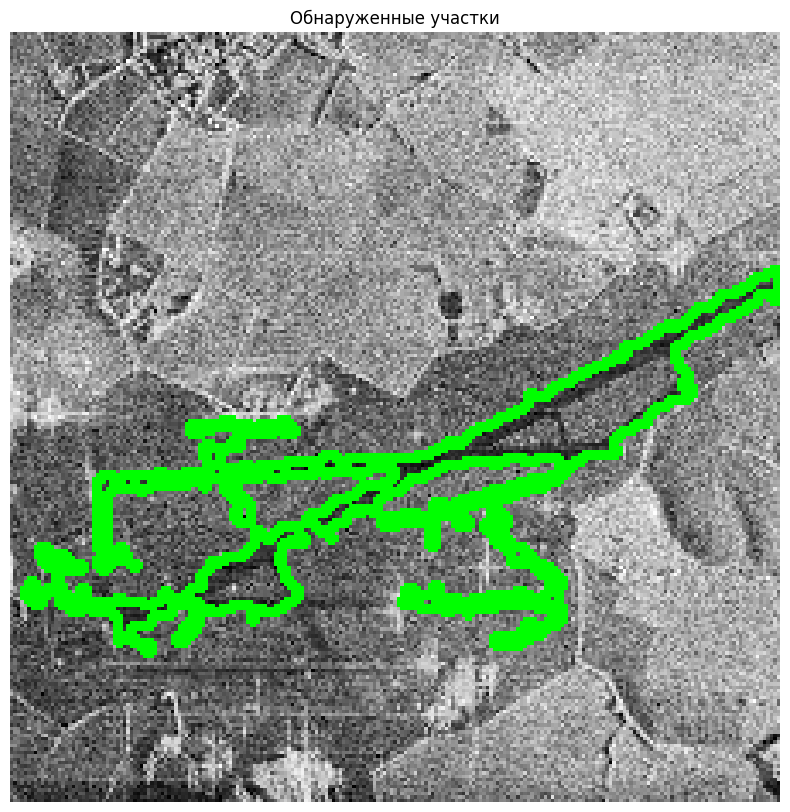

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Загрузка изображения
img_path = 'sar_3.jpg'
img_data = cv2.imread(img_path)

# Преобразование в оттенки серого
gray_img = cv2.cvtColor(img_data, cv2.COLOR_BGR2GRAY)


# Применение различных методов бинаризации
_, simple_binary = cv2.threshold(gray_img, 60, 255, cv2.THRESH_BINARY)
_, otsu_binary = cv2.threshold(gray_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
adaptive_mean = cv2.adaptiveThreshold(gray_img, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 101, 45)

# Отображение результатов бинаризации
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(simple_binary, cmap='gray')
plt.title('Простая бинаризация')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(otsu_binary, cmap='gray')
plt.title('Бинаризация Оцу')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(adaptive_mean, cmap='gray')
plt.title('Адаптивная бинаризация (среднее)')
plt.axis('off')

plt.show()

# Обнаружение границ с использованием детектора Канни
edge_detection = cv2.Canny(gray_img, 100, 150, apertureSize=3)

# Поиск линий с использованием преобразования Хафа
detected_lines = cv2.HoughLines(edge_detection, 1, np.pi / 180, 140)

# Поиск самой длинной линии
best_length = 0
best_line_coords = None

if detected_lines is not None:
    for current_line in detected_lines:
        rho_val, theta_val = current_line[0]
        cos_theta = np.cos(theta_val)
        sin_theta = np.sin(theta_val)
        start_x = int(cos_theta * rho_val - 1000 * sin_theta)
        start_y = int(sin_theta * rho_val + 1000 * cos_theta)
        end_x = int(cos_theta * rho_val + 1000 * sin_theta)
        end_y = int(sin_theta * rho_val - 1000 * cos_theta)
        line_length = np.sqrt((start_x - end_x) ** 2 + (start_y - end_y) ** 2)
        if line_length > best_length:
            best_length = line_length
            best_line_coords = ((start_x, start_y), (end_x, end_y))

# Отображение самой длинной линии на изображении
if best_line_coords is not None:
    img_with_line = img_data.copy()
    cv2.line(img_with_line, best_line_coords[0], best_line_coords[1], (0, 255, 0), 3, cv2.LINE_AA) 
plt.imshow(cv2.cvtColor(img_with_line, cv2.COLOR_BGR2RGB))
plt.title('Самая длинная линия')
plt.axis('off')
plt.show()
print(f"Длина самой длинной линии: {best_length:.2f} пикселей")

# Размытие и адаптивная бинаризация
blurred_img = cv2.GaussianBlur(adaptive_mean, (7, 7), 0)
adaptive_gaussian = cv2.adaptiveThreshold(blurred_img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)
contours_list, _ = cv2.findContours(adaptive_gaussian, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
road_image = img_data.copy()
if contours_list:
    for contour in contours_list:
        contour_area = cv2.contourArea(contour)
        if contour_area > 500:
            cv2.drawContours(road_image, [contour], -1, (0, 255, 0), 2)  

# Отображение контуров
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(road_image, cv2.COLOR_BGR2RGB))
plt.title('Обнаруженные участки')
plt.axis('off')
plt.show()